# Prototype de priorisation des événements de sécurité



## 0. Imports

In [84]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # à conserver pour que vos résultats soient reproductibles

## 1. Chargement des données

In [85]:
RAW_DATA_DIR = os.path.join("..","data", "processed")

In [86]:
df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'cleaned_dataset.csv'))
df.head()

,timestamp,source,event_id,user_id,device_id,src_ip,src_ip_valid,event_type,process_name,severity,...,employment_status,privileged_account,hostname,asset_type,asset_owner,asset_criticality,user_known,device_known,label,triage_label
0,2026-03-02 01:31:00,authentication_logs,AUTH003692,U0190,D0154,10.27.255.130,True,MFA_CHALLENGE,UNKNOWN,MEDIUM,...,ACTIVE,YES,PHF-LT-0154,Mobile,Finance,HIGH,True,True,UNLABELED,SUSPICIOUS
1,2026-03-02 01:41:00,authentication_logs,AUTH000733,U0008,D0029,10.21.247.242,True,LOGOUT,UNKNOWN,LOW,...,ACTIVE,NO,PHF-WS-0029,Server,IT,CRITICAL,True,True,UNLABELED,MALICIOUS
2,2026-03-02 01:53:00,authentication_logs,AUTH000859,U0343,D0025,10.12.238.24,True,LOGIN,UNKNOWN,MEDIUM,...,ACTIVE,NO,PHF-WS-0025,Laptop,RH,LOW,True,True,UNLABELED,NORMAL
3,2026-03-02 02:32:15,authentication_logs,AUTH002474,U0202,D0053,10.42.152.134,True,PASSWORD_CHANGE,UNKNOWN,MEDIUM,...,ACTIVE,NO,PHF-SRV-0053,Server,Regions,MEDIUM,True,True,UNLABELED,SUSPICIOUS
4,2026-03-02 02:50:24,authentication_logs,AUTH002027,U0226,D0041,10.39.189.42,True,MFA_CHALLENGE,UNKNOWN,LOW,...,ACTIVE,NO,PHF-SRV-0041,VM,Direction,CRITICAL,True,True,UNLABELED,SUSPICIOUS


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6702 entries, 0 to 6701
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   timestamp              6702 non-null   object
 1   source                 6702 non-null   object
 2   event_id               6702 non-null   object
 3   user_id                6702 non-null   object
 4   device_id              6702 non-null   object
 5   src_ip                 6702 non-null   object
 6   src_ip_valid           6702 non-null   bool  
 7   event_type             6702 non-null   object
 8   process_name           6702 non-null   object
 9   severity               6702 non-null   object
 10  authentication_result  6702 non-null   object
 11  location               6702 non-null   object
 12  user_department        6702 non-null   object
 13  user_role              6702 non-null   object
 14  employment_status      6702 non-null   object
 15  privileged_account   

## 2. Analyse de la cible

Distribution des trois classes

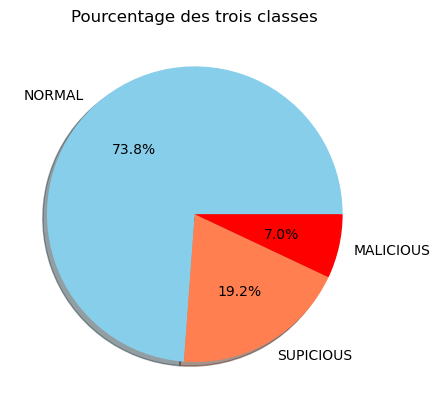

triage_label
NORMAL        4948
SUSPICIOUS    1284
MALICIOUS      470
Name: count, dtype: int64


In [88]:
# Pourcentage des trois classes

labels = ['NORMAL','SUPICIOUS','MALICIOUS']

df["triage_label"].value_counts().plot.pie(autopct="%1.1f%%", labels=labels, colors=["skyblue","coral", "red"],shadow=True)
plt.title("Pourcentage des trois classes")
plt.ylabel("")
plt.show()

print(df['triage_label'].value_counts())

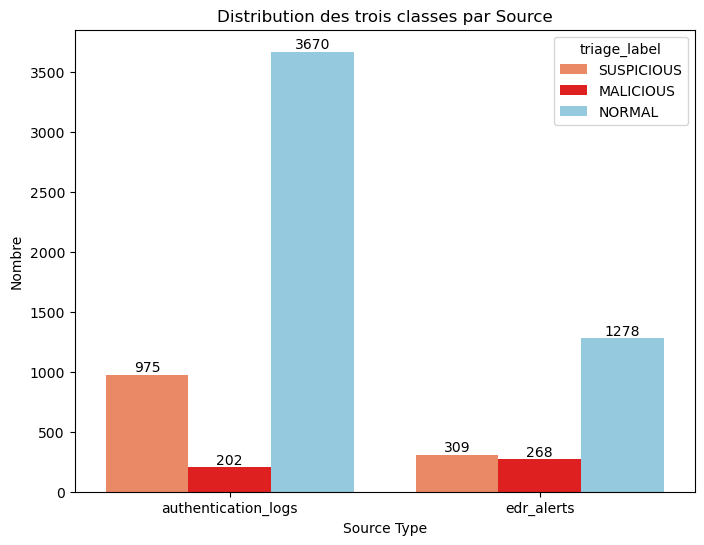

In [89]:
# Distribution par Source
plt.figure(figsize=(8,6))

ax = sns.countplot(x='source', hue='triage_label', data=df,
                   order=df['source'].value_counts(ascending=False).index,
                   palette=["coral","red" ,"skyblue"])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution des trois classes par Source')
plt.ylabel('Nombre')
plt.xlabel('Source Type')
plt.show()

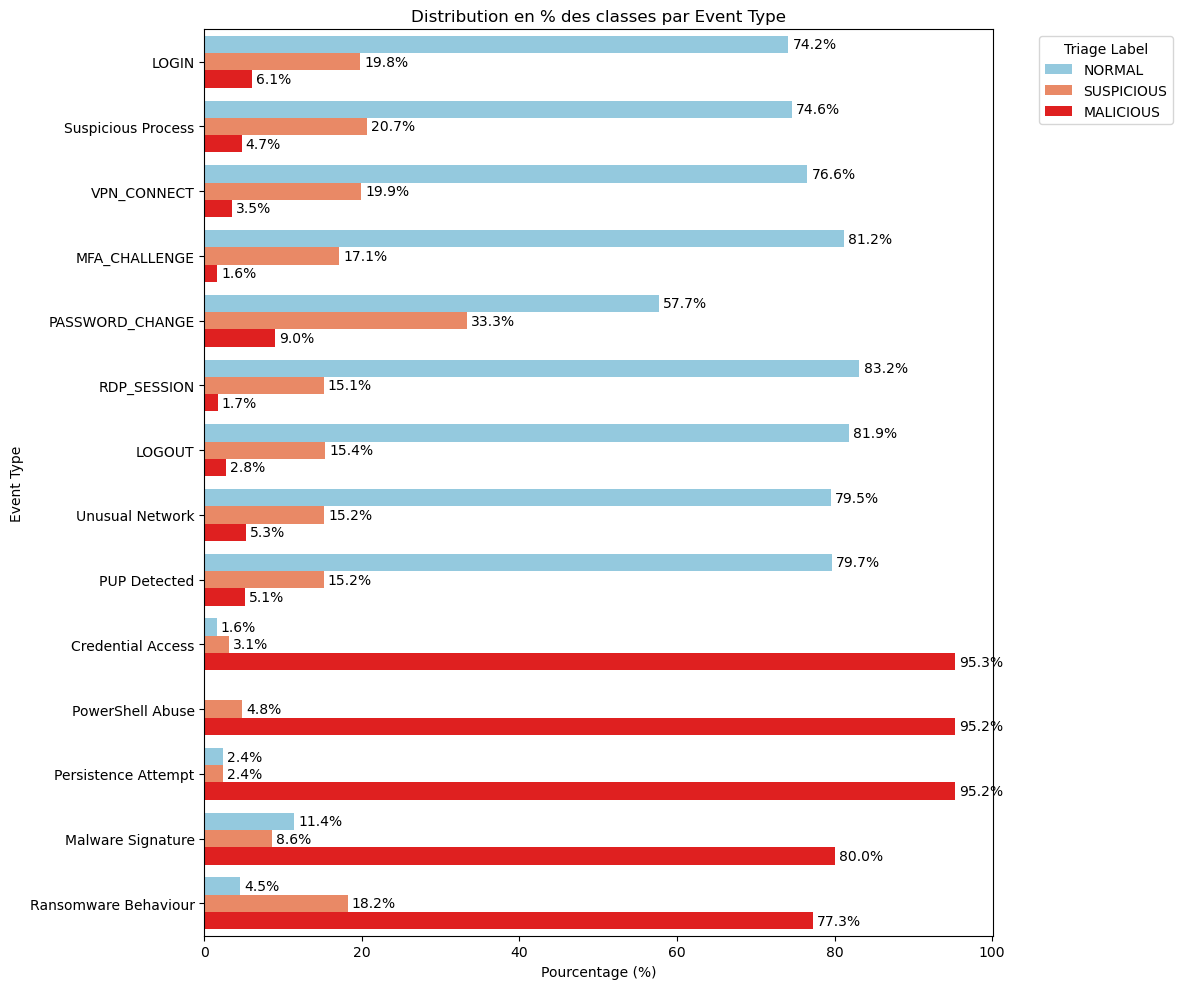

In [90]:
# Distribution par Event type
plt.figure(figsize=(12, 10))

# Calcul des pourcentages par type d'événement
counts = df.groupby(['event_type', 'triage_label']).size().reset_index(name='count')
totals = counts.groupby('event_type')['count'].transform('sum')
counts['percentage'] = (counts['count'] / totals) * 100

# Définition de l'ordre (basé sur la fréquence totale des événements)
event_order = df['event_type'].value_counts().index

ax = sns.barplot(x='percentage', y='event_type', hue='triage_label', data=counts,
                   order=event_order,
                   hue_order=['NORMAL', 'SUSPICIOUS', 'MALICIOUS'],
                   palette=["skyblue","coral","red"])

# Ajout des étiquettes de pourcentage sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Distribution en % des classes par Event Type')
plt.xlabel('Pourcentage (%)')
plt.ylabel('Event Type')
plt.legend(title='Triage Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 Après vérification, le jeu de données présente un fort déséquilibre de classes, caractérisé par une écrasante majorité d'événements normaux. Si le modèle de Machine Learning se contente de prédire systématiquement cette classe majoritaire, il échouera à détecter les vrais positifs (les activités suspectes ou malveillantes). Pour la surveillance de sécurité, les conséquences d'un tel biais seraient critiques, car de véritables cyberattaques passeraient totalement inaperçues au travers de nos défenses

## 3. Colonnes utilisables et fuite de cible



Les colonnes à exclure:
 * **triage_label** - La Variable Cible (Target) :  Il s'agit de la variable cible que le modèle doit apprendre à prédire. Elle représente la conclusion finale portée sur l'événement après une investigation complète de l'incident. Elle est par définition inconnue au moment où l'événement arrive.
 * **label** : Cette colonne contient la décision historique rendue par l'analyste lors du traitement de l'alerte à l'époque. L'utiliser pour entraîner le modèle provoquerait un surapprentissage.
 * **event_id** : C'est une clé technique unique de haute cardinalité sans aucun pouvoir statistique ou prédictif pour un algorithme.
 * **user_id**, **device_id** et **src_ip** : exclut sur sa forme brute. Motif : Ces champs possèdent une cardinalité trop élevée (chaque utilisateur/machine a un identifiant unique), ce qui entraînerait un surapprentissage massif. Toutefois, ils sont disponibles à T=0 et doivent impérativement être utilisés pour le Feature Engineering glissant (ex. : nombre d'échecs de connexion récents pour un utilisateur, volume d'activité récent d'une machine).




## 4. Feature engineering


Le fichier ne contient qu'un événement par ligne. Certains signaux ne se voient qu'en regardant l'historique d'une même entité :

-	recent_failed_user_20m : nombre d'échecs d'authentification récents pour le même utilisateur (fenêtre de 20 min) ;
-	success_after_failures : un succès qui arrive juste après une série d'échecs;
-	hour, is_night, day_of_week, is_weekend,is_day : caractéristiques temporelles ;
-	user_event_count, device_event_count : volume d'activité par entité ;
-	unusual_location : localisation inhabituelle ;
-	is_admin, is_privileged, is_inactive_account : croisement avec le profil de l'utilisateur ;



In [91]:
df_feature = df.copy()

In [92]:
# Feature Engineering caractéristiques temporelles (heure, nuit/jour, jour de semaine)

df_feature["datetime"] = pd.to_datetime(df["timestamp"])

#  Heure brute (0-23)
df_feature["hour"] = df_feature["datetime"].dt.hour.fillna(-1).astype(int)

# Indicateur nuit (1 si entre 20h00 et 05h59, 0 sinon, -1 si heure invalide)
df_feature["is_night"] = df_feature["hour"].apply(lambda h: -1 if h == -1 else (1 if (h >= 20 or h < 6) else 0))

# . Indicateur jour (1 si entre 06h00 et 19h59, 0 sinon, -1 si heure invalide)
df_feature["is_day"] = df_feature["hour"].apply(lambda h: -1 if h == -1 else (1 if (6 <= h < 20) else 0))

# . Jour de la semaine (0 = Lundi, 6 = Dimanche)
df_feature["day_of_week"] = df_feature["datetime"].dt.dayofweek

# Week-end
df_feature["is_weekend"] = (df_feature["day_of_week"] >= 5).astype(int)


In [93]:
# Signal : échecs récents du même utilisateur dans les 20 minutes précédentes
auth_failed = (
    (df_feature["source"] == "authentication_logs") &
    (df_feature["authentication_result"] == "FAILED") &
    (df_feature["user_id"] != "UNKNOWN")
)
failed = df_feature.loc[auth_failed, ["datetime", "user_id"]].copy()

recent_failed_user = []
for _, row in df_feature.iterrows():
    t, uid = row["datetime"], row["user_id"]
    if pd.isna(t) or uid == "UNKNOWN":
        recent_failed_user.append(0)
        continue
    m = (failed["user_id"] == uid) & (failed["datetime"] < t) & (failed["datetime"] >= t - pd.Timedelta(minutes=20))
    recent_failed_user.append(int(m.sum()))
df_feature["recent_failed_user_20m"] = recent_failed_user

In [94]:
# Succès après une série d'échecs : seuil opérationnel choisi = au moins 3 échecs récents
df_feature["success_after_failures"] = (
    (df_feature["authentication_result"] == "SUCCESS") &
    (df_feature["recent_failed_user_20m"] >= 3)
).astype(int)


In [95]:
# Admin Accounts and criticality
df_feature["is_admin"] = (df_feature["privileged_account"]=="YES").astype(int)

criticality = {

    "LOW":1,
    "MEDIUM":2,
    "HIGH":3,
    "CRITICAL":4,
    "UNKNOWN":0

}

df_feature["criticality_score"] = df_feature["asset_criticality"].map(criticality)

In [96]:
# Volume d'activité dans les 20 minutes précédentes
user_activity = df_feature.groupby("user_id").size()

df_feature["user_event_count"] = df_feature["user_id"].map(user_activity)

device_activity = df_feature.groupby("device_id").size()

df_feature["device_event_count"] = df_feature["device_id"].map(device_activity)

In [97]:
# Détection d'une localisation inhabituelle pour l'utilisateur

unusual_location = []

# Dictionnaire contenant les localisations déjà observées
user_locations = {}

for _, row in df_feature.iterrows():

    uid = row["user_id"]
    location = row["location"]

    # Cas non exploitables
    if uid == "UNKNOWN" or pd.isna(location) or location == "UNKNOWN":
        unusual_location.append(0)
        continue

    # Premier événement connu de l'utilisateur :
    # pas assez d'historique pour conclure
    if uid not in user_locations:
        unusual_location.append(0)
        user_locations[uid] = {location}
        continue

    # Vérifier si la localisation a déjà été observée
    if location in user_locations[uid]:
        unusual_location.append(0)
    else:
        unusual_location.append(1)

    # Ajouter la localisation à l'historique
    user_locations[uid].add(location)


df_feature["unusual_location"] = unusual_location

In [98]:
# 1 = compte inactif, 0 = compte actif
df_feature["is_inactive_account"] = (
    df_feature["employment_status"] == "INACTIVE"
).astype(int)

In [99]:
df_feature.head()

,timestamp,source,event_id,user_id,device_id,src_ip,src_ip_valid,event_type,process_name,severity,...,day_of_week,is_weekend,recent_failed_user_20m,success_after_failures,is_admin,criticality_score,user_event_count,device_event_count,unusual_location,is_inactive_account
0,2026-03-02 01:31:00,authentication_logs,AUTH003692,U0190,D0154,10.27.255.130,True,MFA_CHALLENGE,UNKNOWN,MEDIUM,...,0,0,0,0,1,3,24,39,0,0
1,2026-03-02 01:41:00,authentication_logs,AUTH000733,U0008,D0029,10.21.247.242,True,LOGOUT,UNKNOWN,LOW,...,0,0,0,0,0,4,20,33,0,0
2,2026-03-02 01:53:00,authentication_logs,AUTH000859,U0343,D0025,10.12.238.24,True,LOGIN,UNKNOWN,MEDIUM,...,0,0,0,0,0,1,18,43,0,0
3,2026-03-02 02:32:15,authentication_logs,AUTH002474,U0202,D0053,10.42.152.134,True,PASSWORD_CHANGE,UNKNOWN,MEDIUM,...,0,0,0,0,0,2,21,31,0,0
4,2026-03-02 02:50:24,authentication_logs,AUTH002027,U0226,D0041,10.39.189.42,True,MFA_CHALLENGE,UNKNOWN,LOW,...,0,0,0,0,0,4,27,21,0,0


## 5. Séparation train / test


In [100]:
# Exclusion des colonnes comme indiqué dans l'étape 3
# identifiants quasi uniques / cible / historique post-investigation / timestamp brut

exclude = ["triage_label", "label", "event_id", "timestamp", "datetime","user_id","device_id","hostname","src_ip","asset_owner"]
features = [c for c in df_feature.columns if c not in exclude]


In [101]:
#  train_test_split stratifié
X = df_feature[features]
y = df_feature["triage_label"]

# Colonnes numériques
num_cols = X.select_dtypes(include="number").columns.tolist()

# Colonnes catégorielles
cat_cols = X.select_dtypes(include=["object","bool"]).columns.tolist()

print(num_cols)
print(cat_cols)

print(len(num_cols))
print(len(cat_cols))

print(X.shape)
print(y.shape)


['hour', 'is_night', 'is_day', 'day_of_week', 'is_weekend', 'recent_failed_user_20m', 'success_after_failures', 'is_admin', 'criticality_score', 'user_event_count', 'device_event_count', 'unusual_location', 'is_inactive_account']
['source', 'src_ip_valid', 'event_type', 'process_name', 'severity', 'authentication_result', 'location', 'user_department', 'user_role', 'employment_status', 'privileged_account', 'asset_type', 'asset_criticality', 'user_known', 'device_known']
13
15
(6702, 28)
(6702,)


In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

## 6. Preprocessing

In [103]:
#  ColumnTransformer + Pipeline

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


## 7. Baseline


In [104]:
#  baseline

# Création du pipeline
baseline = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(
         strategy="most_frequent",
    ))
])


baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [105]:
# Évaluation de la baseline
print("=== BASELINE ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_baseline,average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

=== BASELINE ===
Accuracy : 0.738
F1 Score: 0.283

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.00      0.00      0.00        94
      NORMAL       0.74      1.00      0.85       990
  SUSPICIOUS       0.00      0.00      0.00       257

    accuracy                           0.74      1341
   macro avg       0.25      0.33      0.28      1341
weighted avg       0.55      0.74      0.63      1341



## 8. Entraînement  modèles


In [106]:
# Modèle 1

# Modèle de regression logistique
log_reg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver='lbfgs',
        penalty='l2',
        C=15
    ))
])


# Entraînement du modèle
log_reg.fit(X_train, y_train)

# Prédictions
y_pred_log = log_reg.predict(X_test)



In [107]:
# Modèle 2

# Modèle de random forest
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        min_samples_split=10,
        max_depth=10,
        n_jobs=1
    ))
])


# Entraînement du modèle
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)




## 9. Évaluation


=== LOGISTIC REGRESSION ===
Accuracy : 0.755
Macro F1 : 0.708

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.67      0.81      0.73        94
      NORMAL       0.97      0.74      0.84       990
  SUSPICIOUS       0.43      0.78      0.55       257

    accuracy                           0.75      1341
   macro avg       0.69      0.78      0.71      1341
weighted avg       0.84      0.75      0.78      1341



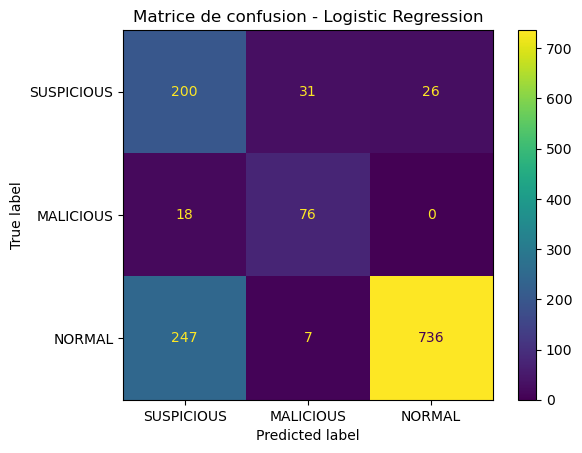

In [108]:
# Evaluation comparée
# Résultats
labels =df['triage_label'].unique().tolist()

print("=== LOGISTIC REGRESSION ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 3))
print("Macro F1 :", round(f1_score(y_test, y_pred_log, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_log, zero_division=0))


# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    labels=labels
)

plt.title("Matrice de confusion - Logistic Regression")
plt.grid(False)
plt.show()

La régression logistique obtient une accuracy de 76 % et un macro F1 de 0,71. Le modèle présente surtout un recall de 81 % sur la classe MALICIOUS. Sur les 118 événements réellement malveillants, 94 sont classés MALICIOUS et 18 SUSPICIOUS. Aucun événement MALICIOUS n'est classé NORMAL.En contrepartie, le modèle génère davantage de faux positifs, notamment 246 événements NORMAL classés SUSPICIOUS. Le modèle privilégie donc la détection des menaces au prix d'une augmentation de la charge d'investigation des analystes.

=== RANDOM FOREST ===
Accuracy : 0.791
F1 : 0.719

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.71      0.70      0.71        94
      NORMAL       0.94      0.82      0.87       990
  SUSPICIOUS       0.48      0.73      0.58       257

    accuracy                           0.79      1341
   macro avg       0.71      0.75      0.72      1341
weighted avg       0.84      0.79      0.81      1341



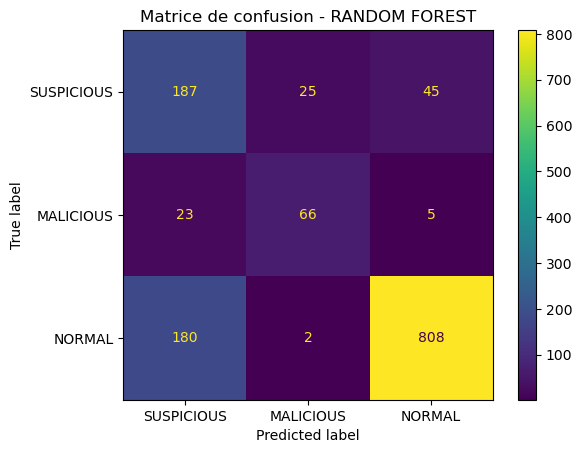

In [109]:
# Résultats
print("=== RANDOM FOREST ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("F1 :", round(f1_score(y_test, y_pred_rf, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_rf, zero_division=0))


# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=labels
)

plt.title("Matrice de confusion - RANDOM FOREST")
plt.grid(False)
plt.show()

Random Forest est meilleure pour reconnaître les événements normaux, mais Logistic Regression est meilleure pour ne pas laisser passer les événements malveillants.

La Random Forest obtient une accuracy de 80 % et un F1 de 0.72. Elle reconnaît particulièrement bien la classe NORMAL avec un recall de 94 %. Cependant, son recall pour la classe MALICIOUS n'est que de 70 %. Sur 94 événements réellement malveillants, 68 sont correctement classés MALICIOUS, 23 sont classés SUSPICIOUS et 5 sont classés NORMAL. Ces 5 faux négatifs représentent un risque important pour le SOC car ils pourraient ne pas être investigués. En comparaison, la régression logistique classe 0 événements MALICIOUS comme NORMAL. Malgré une performance globale plus faible, la régression logistique apparaît donc plus adaptée à l'objectif métier de détection des incidents.

## 10. Analyse des erreurs et arbitrage métier

 Un faux négatif est plus critique qu'un faux positif.
Un faux positif augmente la charge de travail des analystes, tandis qu'un événement MALICIOUS classé NORMAL risque de ne jamais être investigué.
Il faut privilieger un modèle capable de limiter les faux négatifs, même au prix d'une augmentation des faux positifs.



In [110]:

# Matrices de confusion
cm_log = confusion_matrix(y_test, y_pred_log, labels=labels)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)


# Récupérer les principales erreurs
comparaison = pd.DataFrame({
    "Erreur": [
        "MALICIOUS → NORMAL",
        "MALICIOUS → SUSPICIOUS",
        "SUSPICIOUS → NORMAL",
        "NORMAL → SUSPICIOUS",
        "NORMAL → MALICIOUS"
    ],

    "Logistic Regression": [
        cm_log[1, 2],
        cm_log[1, 0],
        cm_log[0, 2],
        cm_log[2, 0],
        cm_log[2, 1]
    ],

    "Random Forest": [
        cm_rf[1, 2],
        cm_rf[1, 0],
        cm_rf[0, 2],
        cm_rf[2, 0],
        cm_rf[2, 1]
    ]
})

comparaison

,Erreur,Logistic Regression,Random Forest
0,MALICIOUS → NORMAL,0,5
1,MALICIOUS → SUSPICIOUS,18,23
2,SUSPICIOUS → NORMAL,26,45
3,NORMAL → SUSPICIOUS,247,180
4,NORMAL → MALICIOUS,7,2


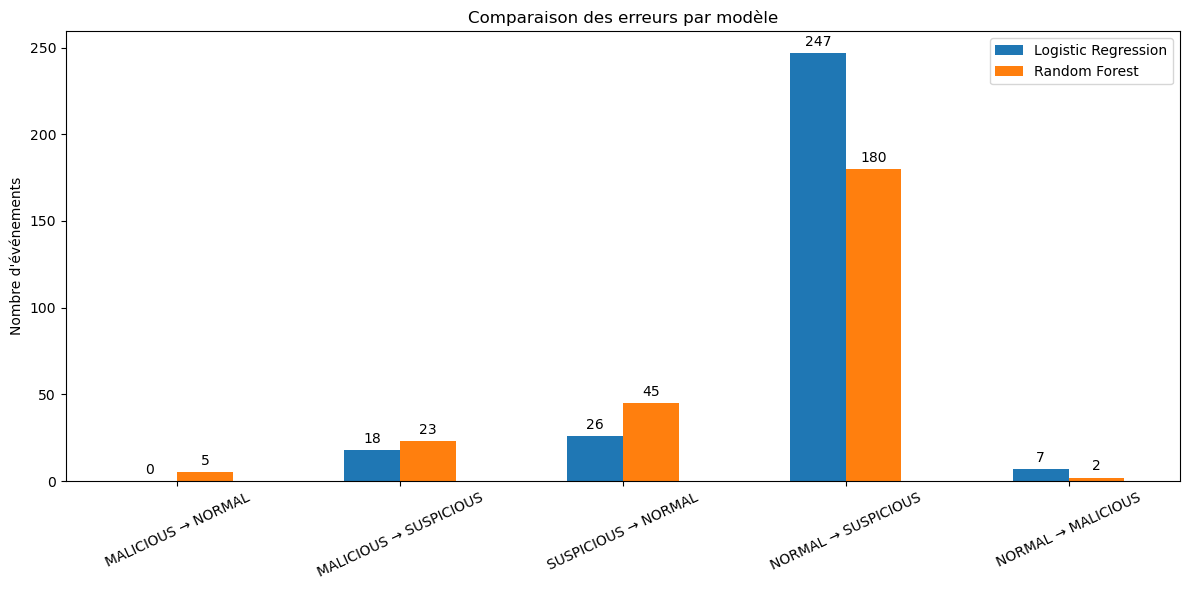

In [111]:
ax = comparaison.plot(
    x="Erreur",
    kind="bar",
    figsize=(12, 6)
)

# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Comparaison des erreurs par modèle")
plt.ylabel("Nombre d'événements")
plt.xlabel("")
plt.xticks(rotation=25)
plt.grid(False)
plt.tight_layout()
plt.show()

Dans le contexte, on peut consider que le faux négatif est plus grave que le faux positif.

Un faux positif signifie qu'un événement NORMAL est classé SUSPICIOUS ou MALICIOUS. Il sera donc investigué inutilement. Cela augmente la charge de travail des analystes et peut provoquer une fatigue liée au nombre d'alertes. Cet impact est important puisque le projet dispose d'une équipe sécurité réduite.

Un faux négatif est plus critique : un événement réellement MALICIOUS classé NORMAL risque de ne jamais être investigué. Une attaque réelle pourrait donc passer inaperçue. Le sujet précise d'ailleurs que NORMAL ne nécessite pas d'investigation, tandis que SUSPICIOUS nécessite une vérification humaine.

La Random Forest génère moins de faux positifs, ce qui réduit la charge de travail des analystes. Cependant, elle classe 5 événements MALICIOUS comme NORMAL.

À l'inverse, la régression logistique génère davantage de faux positifs, mais aucun événement MALICIOUS n'est classé NORMAL. Les 18 événements MALICIOUS-SUSPICIOUS restent quant à eux soumis à une vérification humaine.

## 11. Choix du modèle final

Je recommande à la direction la **régression logistique**.

Ce choix ne repose pas uniquement sur l'accuracy ou le F1-score, mais principalement sur les conséquences opérationnelles des erreurs pour le SOC, comme demandé dans le TP.

La **Random Forest** présente un avantage opérationnel : elle génère moins de faux positifs et sollicite donc moins les analystes.

Cependant, la **régression logistique** protège mieux contre le risque que nous considérons comme prioritaire : un événement dangereux qui ne serait pas investigué. Aucun événement MALICIOUS n'est classé NORMAL, contre 5 avec la Random Forest. De plus, elle classe moins d'événements SUSPICIOUS en NORMAL : 26 contre 45.

## 12. Impact projet


## CARTE 1 — Faux positifs

Après les premiers tests du prototype, 35 % des alertes remontées comme suspectes sont considérées comme bénignes par les analystes.

La direction estime que la charge supplémentaire générée devient difficilement acceptable pour une équipe déjà réduite.

## 1. Impact sur le backlog

On ajoute de nouvelles tâches et on les place en priorité haute, car les faux positifs empêchent le déploiement du prototype.

| Tâche ajoutée | Priorité | Responsable | Statut |
|---|---|---|---|
| Analyser les faux positifs | Haute | Analyste SOC / Data Scientist | À faire |
| Identifier les alertes répétitives bénignes | Haute | Analyste SOC | À faire |
| Ajouter des règles de filtrage | Haute | Data Scientist / SOC | À faire |
| Ajuster le modèle et les seuils | Haute | Data Scientist | À faire |
| Réévaluer FP, FN, recall et F1 | Haute | Data Scientist | À faire |
| Validation du nouveau modèle | Haute | Responsable SOC | À faire |

L'ajout d'une **règle de filtrage** est cohérent avec les objectifs du projet : réduire le bruit et limiter les alertes non pertinentes transmises aux analystes.


## 2. Impact sur le planning

Le déploiement est **reporté** et une nouvelle itération est ajoutée avant la mise en production du prototype.

```text
Analyse des faux positifs >> Ajout de règles / ajustement du modèle >> Nouveaux tests >> Validation par le SOC >> Déploiement 

**Impact : élevé** car une étape supplémentaire est nécessaire avant le déploiement.

Réduire les faux positifs sans augmenter fortement le nombre d'événements MALICIOUS classés NORMAL.

Faire une analyse des faux positifs afin d'identifier les événements que le modèle confond avec SUSPICIOUS.

- analyser les caractéristiques des faux positifs ;
- identifier les types d'événements générant le plus de faux positifs ;
- vérifier certaines features comme unusual_location, user_activity_20m ou recent_failed_user_20m ;
- ajuster le modèle ou ses seuils si nécessaire ;
- comparer à nouveau le nombre de faux positifs et le nombre de faux négatifs MALICIOUS.


## 3. Mise àjour du Risk Register

| Risque | Probabilité | Impact | Criticité | Responsable | Réponse |
|---|---|---|---|---|---|
| Trop de faux positifs | Élevée | Élevé | **Élevée** | Data Scientist | Ajuster le modèle et le filtrage |
| Surcharge des analystes | Élevée | Élevé | **Élevée** | Responsable SOC | Réduire les alertes inutiles |
| Fatigue liée aux alertes | Élevée | Élevé | **Élevée** | Responsable SOC | Suivre le taux de faux positifs |
| Augmentation des faux négatifs après ajustement | Moyenne | **Critique** | **Élevée** | Data Scientist | Contrôler `MALICIOUS -> NORMAL` |